In [12]:
!pip install librosa soundfile

In [13]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [14]:
!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification


Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
100% 1.21G/1.21G [00:09<00:00, 256MB/s]
100% 1.21G/1.21G [00:09<00:00, 137MB/s]


In [15]:
!unzip gtzan-dataset-music-genre-classification.zip

Archive:  gtzan-dataset-music-genre-classification.zip
  inflating: Data/features_30_sec.csv  
  inflating: Data/features_3_sec.csv  
  inflating: Data/genres_original/blues/blues.00000.wav  
  inflating: Data/genres_original/blues/blues.00001.wav  
  inflating: Data/genres_original/blues/blues.00002.wav  
  inflating: Data/genres_original/blues/blues.00003.wav  
  inflating: Data/genres_original/blues/blues.00004.wav  
  inflating: Data/genres_original/blues/blues.00005.wav  
  inflating: Data/genres_original/blues/blues.00006.wav  
  inflating: Data/genres_original/blues/blues.00007.wav  
  inflating: Data/genres_original/blues/blues.00008.wav  
  inflating: Data/genres_original/blues/blues.00009.wav  
  inflating: Data/genres_original/blues/blues.00010.wav  
  inflating: Data/genres_original/blues/blues.00011.wav  
  inflating: Data/genres_original/blues/blues.00012.wav  
  inflating: Data/genres_original/blues/blues.00013.wav  
  inflating: Data/genres_original/blues/blues.00014.wa

Verify Files

In [16]:
!ls Data/genres_original

blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock


In [17]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

In [18]:
def extract_features(file_path):
  try:
    y, sr = librosa.load(file_path, duration = 30)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo = float(tempo)

    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs, axis = 1)

    feature_vector = [
        tempo,
        spectral_centroid,
        spectral_bandwidth,
        zcr,
        *mfccs_mean
    ]

    return feature_vector
  except Exception:
    return None

Building Dataset

In [19]:
features = []
labels = []
base_path = "Data/genres_original"

skipped_files = 0

for genre in os.listdir(base_path):
  genre_path = os.path.join(base_path, genre)

  if not os.path.isdir(genre_path):
    continue

  for file in os.listdir(genre_path):
    file_path = os.path.join(genre_path, file)

    feature_vector = extract_features(file_path)

    if feature_vector is not None:
      features.append(feature_vector)
      labels.append(genre)

    else:
      skipped_files += 1

X = np.array(features, dtype = float)
y = np.array(labels)

/tmp/ipykernel_1880/2337646097.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tempo = float(tempo)
/tmp/ipykernel_1880/2337646097.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration = 30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_1880/2337646097.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tempo = float(tempo)


Splitting into Test and Training Dataset

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify = y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Training the Random Forest Model

In [21]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

Training KNN Model

In [22]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_preds = knn.predict(X_test)

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix



<function matplotlib.pyplot.show(close=None, block=None)>

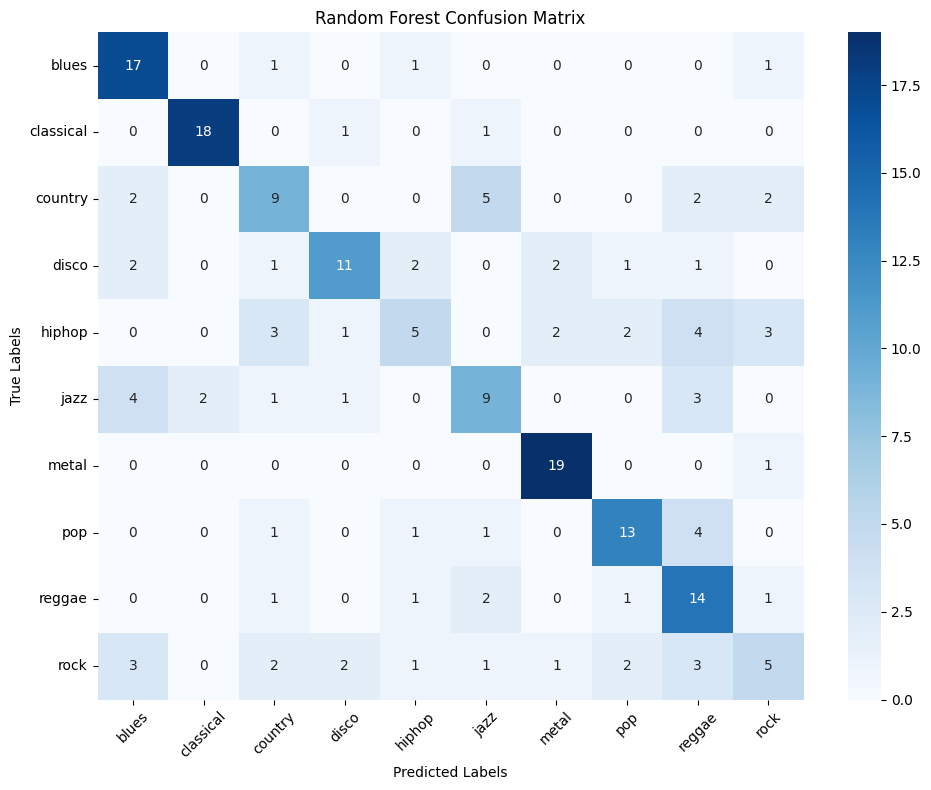

In [24]:
cm_rf = confusion_matrix(y_test, rf_preds, labels=np.unique(y_test))

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test)
  )

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show

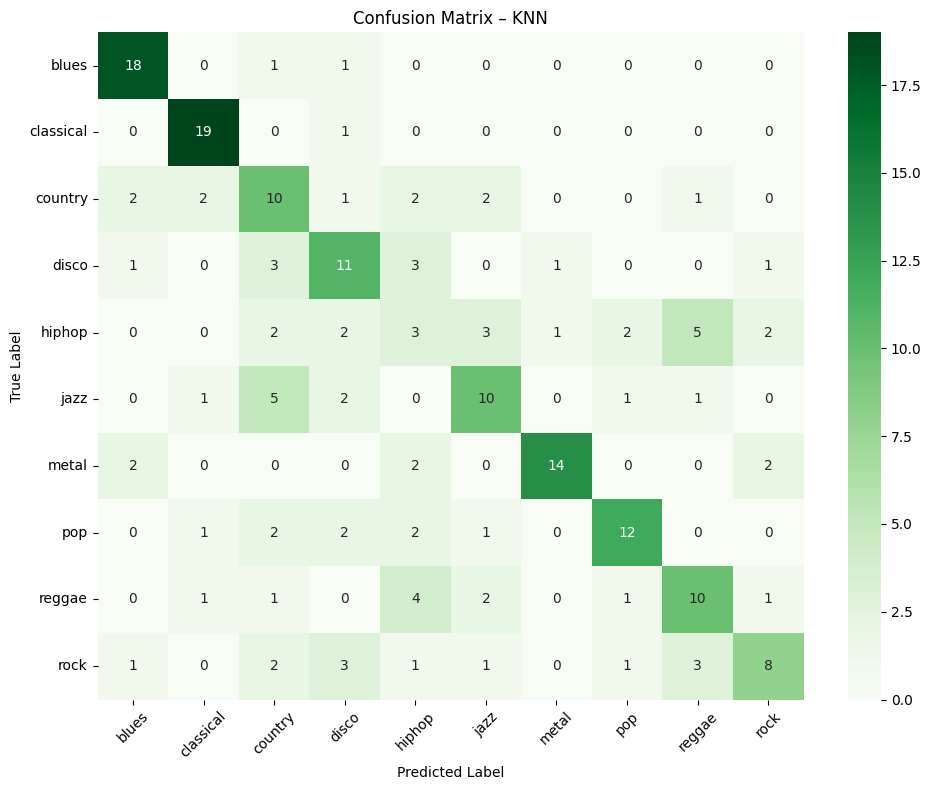

In [25]:
cm_knn = confusion_matrix(y_test, knn_preds, labels=np.unique(y_test))

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=np.unique(y_test),
    yticklabels=np.unique(y_test)
)

plt.title("Confusion Matrix – KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
